In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
from scipy.stats import linregress

# Atividade 2.2 - Regressão Linear, p-value e métricas

## Letra A

### Função ***LinRegress***:

A função ```scipy.stats.linregress``` calcula uma regressão linear de mínimos quadrados para dois conjuntos de medições. Ela devolve a inclinação (slope), o intercepto, o coeficiente de correlação (r-value), o p-value e o erro padrão.

### Código para plotar os gráficos

In [ ]:
def plot_graph(x : np.array, y : np.array, title : str):
    fig, ax = plt.subplots(figsize=(6, 5))
    
    ax.scatter(x, y, color='blue', zorder=10)

    ax.scatter(x, [0.1] * len(x), color='green', zorder=10)
    ax.scatter([0.1] * len(y), y, color='pink', zorder=10)
    
    lr = linregress(x, y)
    
    line_x = np.array([0, 10])
    line_y = lr.slope * line_x + lr.intercept
    
    ax.plot(line_x, line_y, color='black', linestyle='--', linewidth=1)
    
    ax.set_xlabel('Gene X', fontsize=12)
    ax.set_ylabel('Gene Y', fontsize=12)

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)

    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.grid(color='gray', linestyle='-', linewidth=0.5)
    plt.show()
    
    return lr

### Análise dos resultados

Para a geração dos 9 valores necessários para a análise, definimos uma semente para reprodutibilidade. Os valores do primeiro gráfico são $y = x$ no intervalo $[1, 9]$. Os valores do segundo são gerados de forma aleatória para o mesmo intervalo.

--- GRÁFICO 1: CORRELAÇÃO LINEAR ---


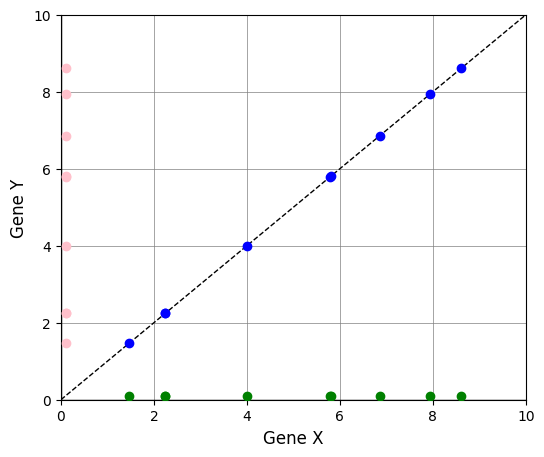

P-value: 3.2926e-70
Covariância: 6.8696
------------------------------

--- GRÁFICO 2: ALEATÓRIO (UNIFORME) ---


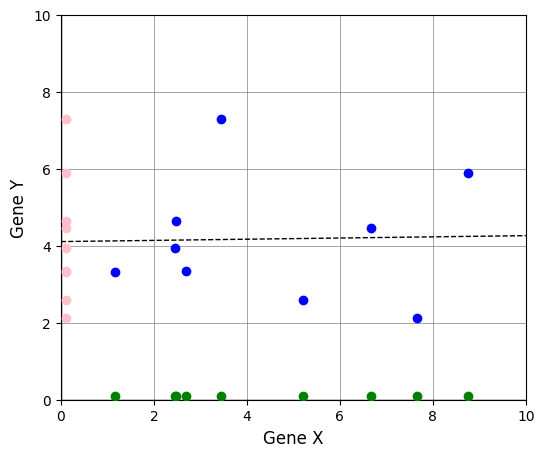

P-value: 0.9484803119891402
Covariância: 0.1098415211025765


In [62]:
np.random.seed(42)

y1 = x1 = np.sort(np.random.uniform(1, 9, 9))

x2 = np.random.uniform(1, 9, 9)
y2 = np.random.uniform(1, 9, 9)

print("--- GRÁFICO 1: CORRELAÇÃO LINEAR ---")
res1 = plot_graph(x1, y1, "Gráfico 1")
cov1 = np.cov(x1, y1)[0, 1]

print(f"P-value: {res1.pvalue:.4e}")
print(f"Covariância: {cov1:.4f}")
print("-" * 30)

print("\n--- GRÁFICO 2: ALEATÓRIO (UNIFORME) ---")
res2 = plot_graph(x2, y2, "Gráfico 2")
cov2 = np.cov(x2, y2)[0, 1]

print(f"P-value: {res2.pvalue}")
print(f"Covariância: {cov2}")

#### **p-value**

O p-value testa a **hipótese nula** de que a inclinação da reta é zero, ou seja, que não existe correlação entre Gene X e Gene Y. 

No primeiro gráfico, observamos que o seu p-value é muito baixo, rejeitando então a **hipótese nula**. Portanto, tem uma relação estaticamente relevante entre o Gene X e o Gene Y.

Já no segundo, observamos que o seu p-value é quase $95\%$. Não podemos rejeitar a **hipotése nula**, já que mostra que o Gene X e o Gene Y não possuem correlação nenhuma.

#### **Covariância**

A covariância indica o grau de interdependência linear entre duas variáveis aleatórias, mostrando se elas se movem na mesma direção (positiva) ou em direções opostas (negativa).

No primeiro gráfico, obtemos uma covariância positiva. Já no segundo, como o valor é proximo de 0 à direita, indica que ela é ligeiramente positiva pelo acaso e não há um padrão claro de variação conjunta.